# импорт нужных библиотек


In [3]:
%pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.3/40.2 MB 3.1 MB/s eta 0:00:13
   -- ------------------------------------- 2.1/40.2 MB 3.4 MB/s eta 0:00:12
   --- ------------------------------------ 3.9/40.2 MB 5.0 MB/s eta 0:00:08
   ----- ---------------------------------- 5.8/40.2 MB 5.8 MB/s eta 0:00:06
   -------- ------------------------------- 8.7/40.2 MB 7.3 MB/s eta 0:00:05
   ------------ --------------------------- 12.8/40.2 MB 9.2 MB/s eta 0:00:03
   --------------- ------------------------ 15.5/40.2 MB 9.7 MB/s eta 0:00:03
   ------------------ --------------------- 18.6/40.2 MB 10.6 MB/s eta 0:00:03
   -------------------- ------------------- 21.0/40.2 MB 10.4 MB/s eta 0:00:02
   ------------------------- -------------- 25.2/40.2 MB 11.4 MB/s eta 0:00:02
   ---------------------------- ----------- 28.8/40.2 MB 11.9 MB/s eta 0:00:01
   

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import cv2

# загрузка фото
разбиение на тензоры RGB
проверка размера

In [26]:
"""создал удобную функцию для изменения размера картинки"""
def do_resize(img, w=640, h=640):
    height, width, _ = img.shape
    print(f"исходный размер {width}x{height}")
    if w!=width and h!=height:
        new_img = cv2.resize(img, (w, h))
        height, width, _ = new_img.shape
        print(f"новый размер {width}x{height}")
        return new_img
    return img

In [ ]:
"""уже читаем картинку через open-cv тоже для удобства"""
img = cv2.imread("img1.jpg")
img = do_resize(img, 640, 640)

исходный размер 1024x1024
новый размер 640x640


In [ ]:
"""поменял этот блок
поменял с BGR на RGB
сделал разбиение на матрицы  по другому"""
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
R,G,B = cv2.split(img)

print(R, G, B)


исходный размер 1024x1024
новый размер 640x640
[[44 50 56 ... 70 69 68]
 [46 46 48 ... 69 68 67]
 [48 44 42 ... 68 67 66]
 ...
 [15 15 15 ... 22 21 21]
 [15 15 15 ... 22 22 21]
 [16 16 16 ... 23 23 22]] [[34 40 45 ... 33 32 31]
 [36 36 37 ... 32 31 30]
 [38 33 31 ... 31 30 29]
 ...
 [22 22 22 ... 21 21 21]
 [22 22 22 ... 22 22 21]
 [23 23 23 ... 23 23 22]] [[35 40 44 ... 17 16 15]
 [36 35 36 ... 16 15 14]
 [37 33 30 ... 15 14 13]
 ...
 [40 40 40 ... 34 33 33]
 [40 40 40 ... 35 34 33]
 [41 41 41 ... 36 34 34]]


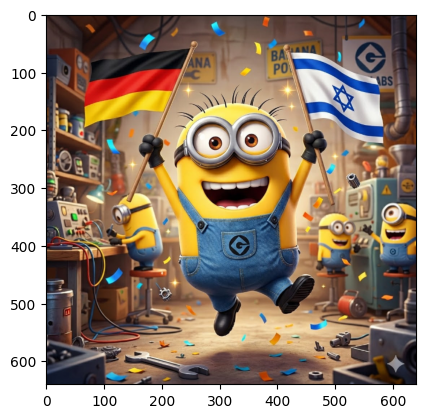

In [10]:
plt.imshow(img)

# степенной метод (пунтк №2)
формула сингулярного разложения: $A=UΣV^T$

In [11]:
def svd(A, singular_values, iter):
  U_cols, sigmas, V_cols = [], [], []
  A_curr = A.copy()

  for _ in range(singular_values):
    # random start vector
    v = np.random.randn(A_curr.shape[1])
    v = v / np.linalg.norm(v)

    # iterations
    for _ in range(iter):
      u = A_curr @ v
      sigma = np.linalg.norm(u)
      u = u / sigma
      v = A_curr.T @ u
      v = v / np.linalg.norm(v)

    U_cols.append(u)
    sigmas.append(sigma)
    V_cols.append(v)
    # вычитаем найденный вклад
    A_curr = A_curr - sigma * np.outer(u, v)

  return np.array(U_cols).T, np.array(sigmas), np.array(V_cols).T

# запуск сингулярного разложения степенным методом

In [12]:
k = 200  # сколько сингулярных чисел берём

for iter in [10, 50, 100]:
    U, Z, V = svd(R, k, iter)
    R_restored = U @ np.diag(Z) @ V.T
    error = np.linalg.norm(R - R_restored)
    print(f'iter={iter}, ошибка={error:.4f}')

iter=10, ошибка=2635.8328
iter=50, ошибка=2631.2335
iter=100, ошибка=2631.1823


ошибка ||A - U∑$V^T$|| показывает насколько воссстановленная матрица отличается от оригинала

результаты при k = 50:
  - iter=10, ошибка=9650.0330
  - iter=50, ошибка=9633.8963
  - iter=100, ошибка=9633.7525

результаты при k = 200:
  - iter=10, ошибка=2562.8590
  - iter=50, ошибка=2556.9908
  - iter=100, ошибка=2556.7037

  ### вывод по пункту 2:
  ошибка падает в зависимости от кол-ва сингулярных чисел и кол-ва итераций (но эт не сильно влияет) ⇒ улучшается точность
  
  !!! после 50 итераций ошибка почти сходится $\rightarrow$ увеличивать кол-во итераций (>100) не имеет смысла

# анализ сингулярных чисел и усеченное SVD (пунткт №3)

связь ошибки усеченного SVD со следующим сингулярным числом: $∥A−A_k​∥=\sigma_{k+1}​$

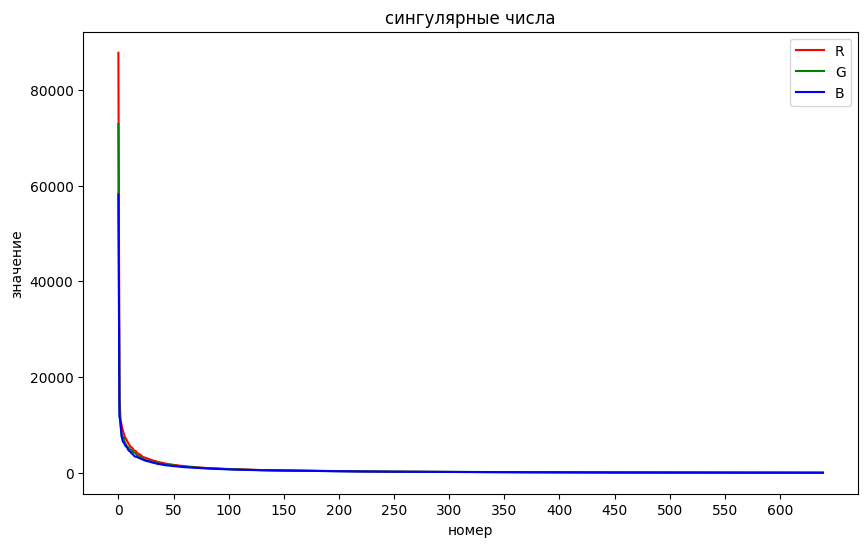

In [25]:
# get singular values
U_r, S_r, V_r = np.linalg.svd(R, full_matrices=False)
U_g, S_g, V_g = np.linalg.svd(G, full_matrices=False)
U_b, S_b, V_b = np.linalg.svd(B, full_matrices=False)

plt.figure(figsize=(10,6))
plt.plot(range(len(S_r)), S_r, color='red',label='R')
plt.plot(range(len(S_g)), S_g, color='green',label='G')
plt.plot(range(len(S_b)), S_b, color='blue',label='B')
plt.xticks(range(0, 640, 50))
plt.xlabel('номер')
plt.ylabel('значение')
plt.title('сингулярные числа')
plt.legend()
plt.show()

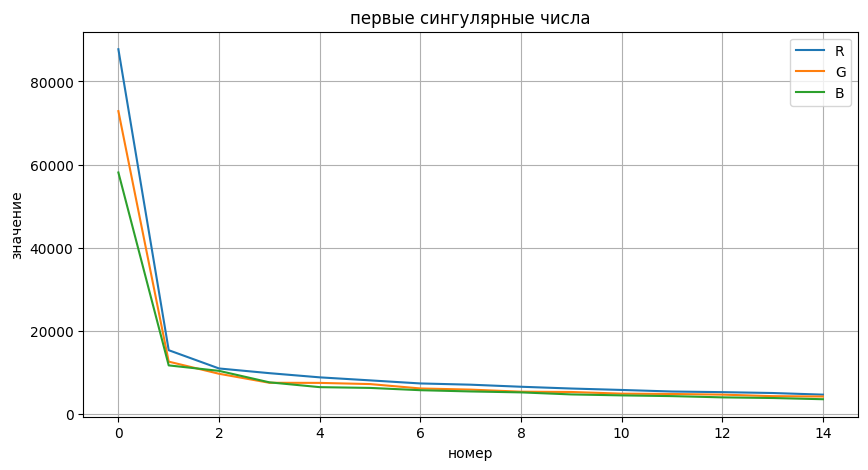

In [ ]:
"""добавил график для первых сингулярных чисел
чисто для наглядности"""
n = 15

plt.figure(figsize=(10, 5))

plt.plot(S_r[:n], label="R")
plt.plot(S_g[:n], label="G")
plt.plot(S_b[:n], label="B")

plt.title("первые сингулярные числа")
plt.xlabel("номер")
plt.ylabel("значение")
plt.grid(True)
plt.legend()
plt.show()

### а) анализ графика
1) резкое падение в начале первые синг числа (<50) огромные (>80000), потом кривая обваливается ⇒ большая часть информации хранится в в первых нескольких компонентах

2) начиная с 50 номера кривая почти плоска, значения не меняются, т.е. их в клад в фотокарточку не значителен

3) все три канала ведут себя схоже, но R > G > B (в начале)

### б) предположить сколько нужно k
кривая резко убывает до 50, после практически не меняется. предположим, что k=range(0, 50) должно быть достаточно для приемлимого качества

### с) реализация усеченного разложения
$A_k =U_kΣ_kV^T_k , k ≪ min(n,m)$

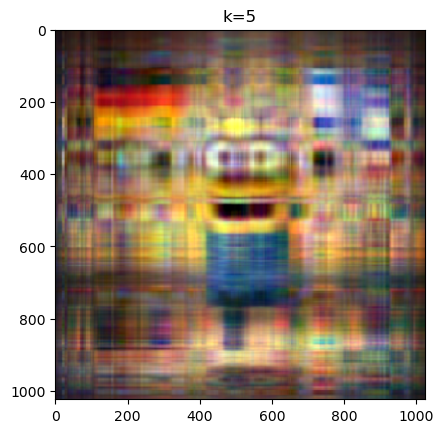

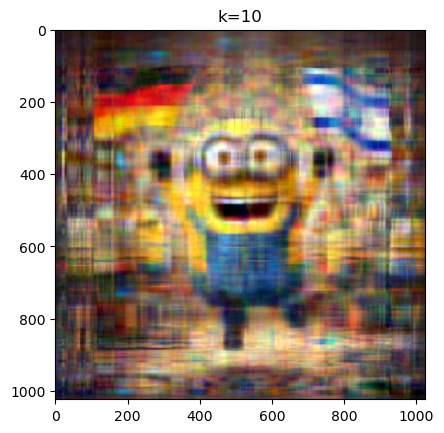

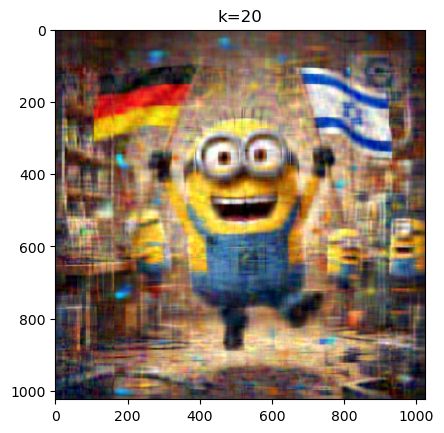

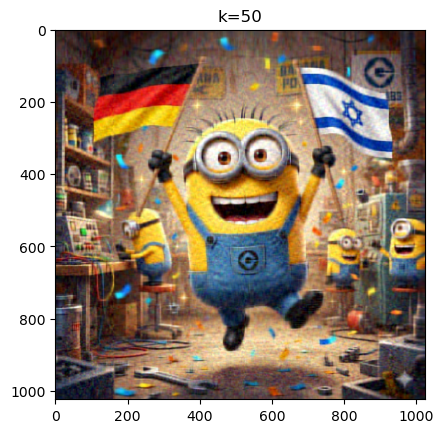

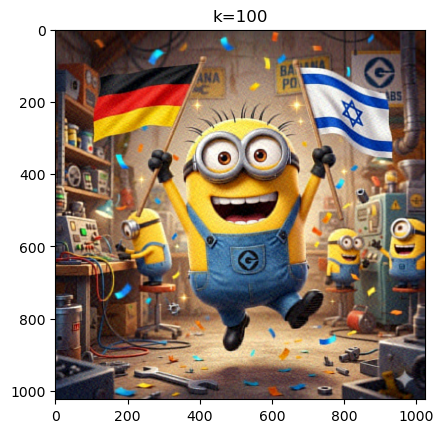

In [ ]:
for k in [5, 10, 20, 50, 100]:
  R_k = U_r[:, :k]  @  np.diag(S_r[:k])  @  V_r[:k, :]
  G_k = U_g[:, :k]  @  np.diag(S_g[:k])  @  V_g[:k, :]
  B_k = U_b[:, :k]  @  np.diag(S_b[:k])  @  V_b[:k, :]

  img_restored = np.clip(np.stack([R_k, G_k, B_k], axis=2), 0, 255).astype(np.uint8)

  plt.figure()
  plt.title(f'k={k}')
  plt.imshow(img_restored)
  plt.show() # хуй

### d) вывод про картинку
картинка после восстановления стало визуально приемлимой на k=50
тк начиная с этого значения картинка визуально не отличается от оригинала, при этом объем данных значительно меньше